# Analiza semiparametryczna: model proporcjonalnych hazardów Coxa

**Projekt:** Analiza czasu trwania — przeżywalność pacjentów z niewydolnością serca  
**Część:** model semiparametryczny  
**Zbiór danych:** `Heart Failure Clinical Records Dataset`

Celem tej części projektu jest zbudowanie i interpretacja modelu Coxa, który pozwala ocenić wpływ cech klinicznych pacjentów na ryzyko zgonu w czasie obserwacji. Notebook zawiera kod, tabele wynikowe, wykresy oraz komentarze interpretacyjne.

In [1]:
# Instalacja brakujących bibliotek — przydatne zwłaszcza w Google Colab
import sys, subprocess, importlib.util

packages = ["pandas", "numpy", "matplotlib", "lifelines", "openpyxl"]
for package in packages:
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("Biblioteki gotowe.")

Biblioteki gotowe.


## 1. Import bibliotek i ustawienia

W analizie wykorzystano bibliotekę `lifelines`, która służy do modelowania danych czasu trwania. Wykresy wykonywane są za pomocą `matplotlib`, aby notebook był możliwie prosty do uruchomienia zarówno w Google Colab, jak i w VS Code.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

OUTPUT_DIR = "wyniki_semiparametryczne_cox"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 2. Wczytanie danych

Plik CSV powinien znajdować się w tym samym katalogu co notebook. W Google Colab można go również wgrać ręcznie po uruchomieniu poniższej komórki.

In [3]:
# Wczytanie pliku CSV
possible_files = [
    "heart_failure_clinical_records_dataset.csv",
    "heart_failure_clinical_records_dataset(1).csv",
]

DATA_FILE = None
for file in possible_files:
    if os.path.exists(file):
        DATA_FILE = file
        break

if DATA_FILE is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        DATA_FILE = list(uploaded.keys())[0]
    except Exception as e:
        raise FileNotFoundError(
            "Nie znaleziono pliku CSV. Umieść plik heart_failure_clinical_records_dataset.csv w katalogu notebooka."
        ) from e

df = pd.read_csv(DATA_FILE)
print(f"Wczytano plik: {DATA_FILE}")
df.head()

Wczytano plik: heart_failure_clinical_records_dataset.csv


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. Kontrola struktury danych

Zbiór obejmuje zmienne kliniczne i demograficzne pacjentów. Zmienną czasu jest `time`, a zmienną zdarzenia `DEATH_EVENT`, gdzie `1` oznacza zgon, a `0` obserwację ocenzurowaną prawostronnie.

In [4]:
print("Wymiary zbioru:", df.shape)
print("\nNazwy kolumn:")
print(df.columns.tolist())

print("\nBraki danych w kolumnach:")
df.isna().sum()

Wymiary zbioru: (299, 13)

Nazwy kolumn:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']

Braki danych w kolumnach:


age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [5]:
# Podstawowe informacje o cenzurowaniu
n = len(df)
events = int(df["DEATH_EVENT"].sum())
censored = n - events

summary_data = pd.DataFrame({
    "Kategoria": ["Zgon", "Obserwacja ocenzurowana"],
    "Liczba pacjentów": [events, censored],
    "Udział [%]": [events / n * 100, censored / n * 100]
})
summary_data

,Kategoria,Liczba pacjentów,Udział [%]
0,Zgon,96,32.107023
1,Obserwacja ocenzurowana,203,67.892977


### Wykres 1. Struktura zdarzeń i obserwacji ocenzurowanych

W analizie przeżycia istotne jest rozróżnienie między pacjentami, u których wystąpiło zdarzenie, oraz pacjentami, dla których obserwacja zakończyła się bez wystąpienia zdarzenia.

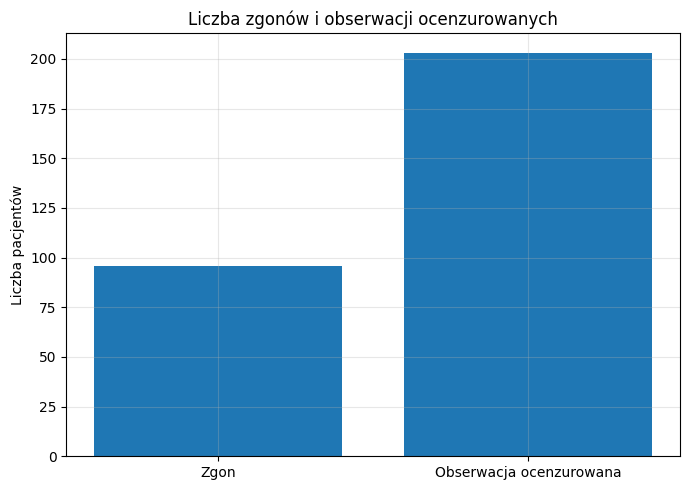

In [6]:
plt.figure(figsize=(7, 5))
plt.bar(summary_data["Kategoria"], summary_data["Liczba pacjentów"])
plt.title("Liczba zgonów i obserwacji ocenzurowanych")
plt.ylabel("Liczba pacjentów")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_struktura_zdarzen.png"), dpi=300)
plt.show()

## 4. Statystyki opisowe wybranych zmiennych

Przed estymacją modelu warto sprawdzić podstawowe charakterystyki zmiennych ilościowych. Pozwala to lepiej zrozumieć zakres wartości zmiennych wykorzystywanych później w modelu Coxa.

In [7]:
opis = df.describe().T
opis.to_csv(os.path.join(OUTPUT_DIR, "statystyki_opisowe.csv"), encoding="utf-8-sig")
opis

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### Wykres 2. Rozkład wieku pacjentów

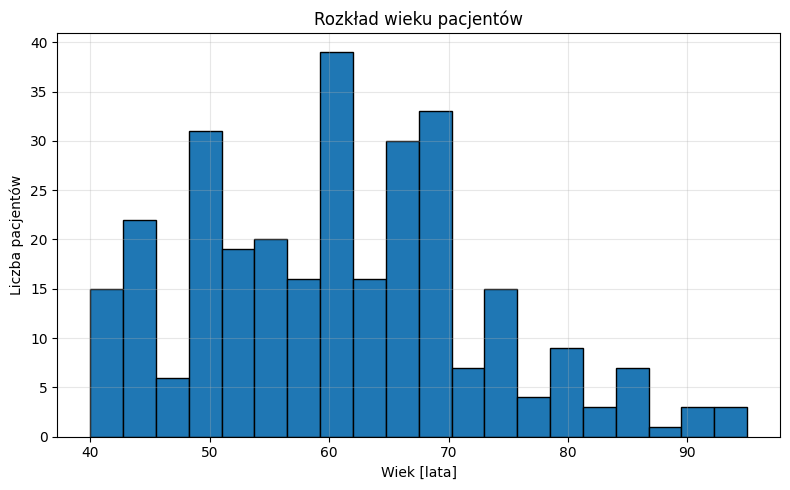

In [8]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, edgecolor="black")
plt.title("Rozkład wieku pacjentów")
plt.xlabel("Wiek [lata]")
plt.ylabel("Liczba pacjentów")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_rozklad_wieku.png"), dpi=300)
plt.show()

### Wykres 3. Rozkład frakcji wyrzutowej serca

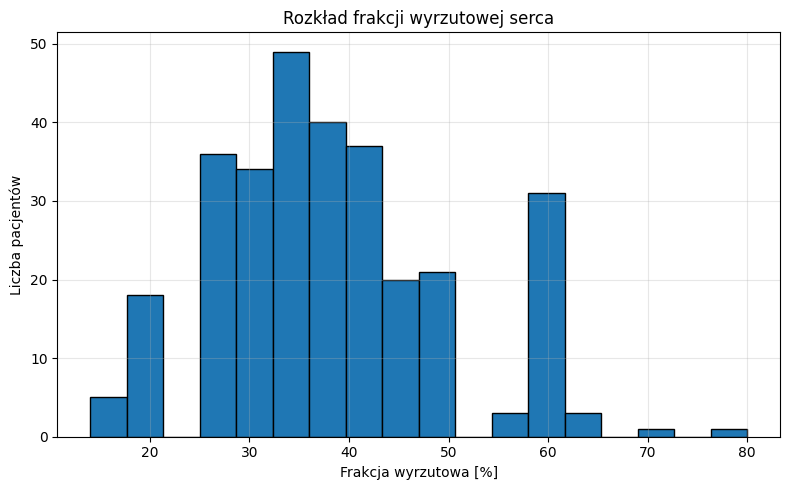

In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["ejection_fraction"], bins=18, edgecolor="black")
plt.title("Rozkład frakcji wyrzutowej serca")
plt.xlabel("Frakcja wyrzutowa [%]")
plt.ylabel("Liczba pacjentów")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_rozklad_frakcji_wyrzutowej.png"), dpi=300)
plt.show()

### Wykres 4. Macierz korelacji zmiennych

Macierz korelacji pomaga ocenić, czy między zmiennymi występują silne zależności liniowe, które mogłyby utrudniać interpretację modelu.

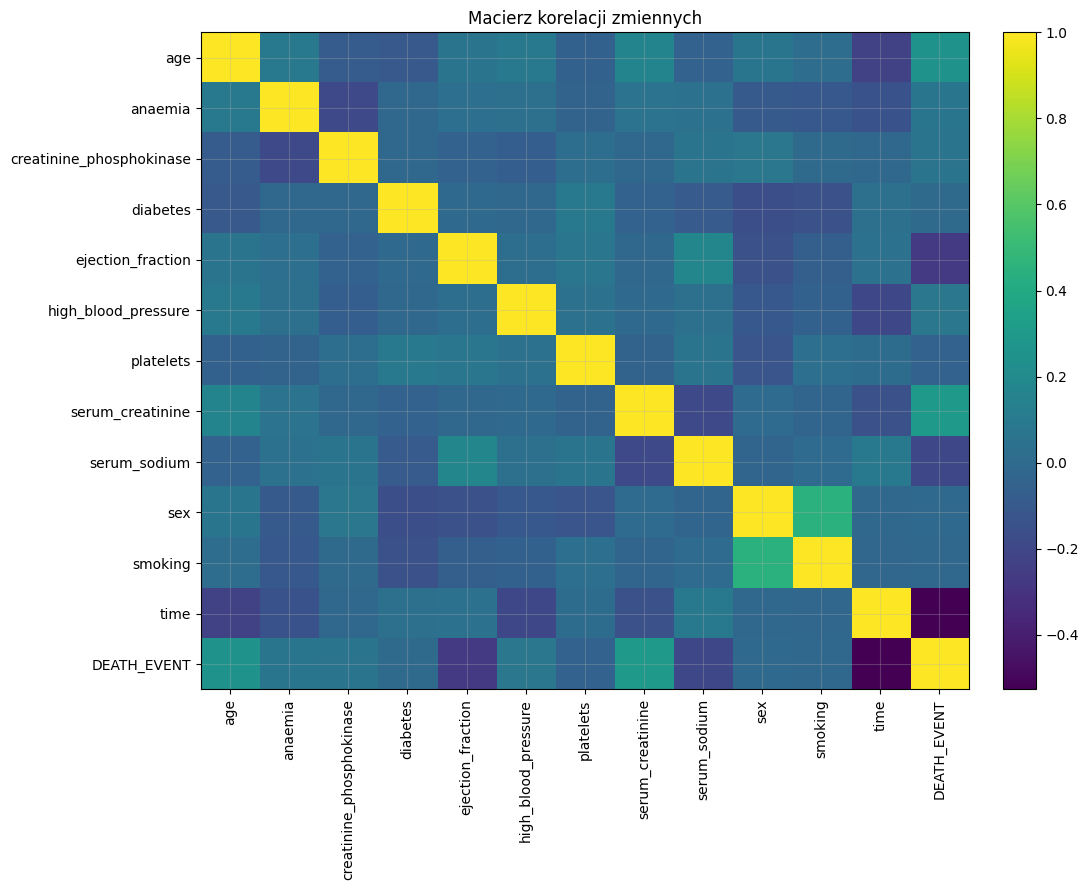

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(11, 9))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Macierz korelacji zmiennych")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_macierz_korelacji.png"), dpi=300)
plt.show()

## 5. Model proporcjonalnych hazardów Coxa

Model Coxa jest modelem semiparametrycznym, ponieważ nie wymaga określenia konkretnego rozkładu czasu przeżycia ani parametrycznej postaci bazowej funkcji hazardu. Model zakłada, że wpływ zmiennych objaśniających działa multiplikatywnie na hazard.

Postać modelu:

$$h(t|X)=h_0(t)\exp(eta_1X_1 + eta_2X_2 + \ldots + eta_pX_p)$$

Najważniejszą miarą interpretacyjną jest **Hazard Ratio**, czyli `exp(coef)`. Wartość większa od 1 oznacza wzrost ryzyka zgonu, a wartość mniejsza od 1 oznacza spadek ryzyka.

In [11]:
# Estymacja modelu Coxa
cph = CoxPHFitter()
cph.fit(df, duration_col="time", event_col="DEATH_EVENT")

cph.print_summary()

<lifelines.CoxPHFitter: fitted with 299 total observations, 203 right-censored observations>
             duration col = 'time'
                event col = 'DEATH_EVENT'
      baseline estimation = breslow
   number of observations = 299
number of events observed = 96
   partial log-likelihood = -468.23
         time fit was run = 2026-06-12 11:02:02 UTC

---
                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                 
age                       0.05      1.05      0.01            0.03            0.06                1.03                1.07
anaemia                   0.46      1.58      0.22            0.04            0.89                1.04                2.42
creatinine_phosphokinase  0.00      1.00      0.00            0.00            0.00                1.00                1.00
diabetes                  0.14      1.15      0.22           -0.30            0.58                0.74                1.78
ejection_fraction        -0.05      0.95      0.01           -0.07           -0.03                0.93                0.97
high_blood_pressure       0.48      1.61      0.22            0.05            0.90                1.05                2.46
platelets                -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
serum_creatinine          0.32      1.38      0.07            0.18            0.46                1.20                1.58
serum_sodium             -0.04      0.96      0.02           -0.09            0.00                0.91                1.00
sex                      -0.24      0.79      0.25           -0.73            0.26                0.48                1.29
smoking                   0.13      1.14      0.25           -0.36            0.62                0.70                1.86

                          cmp to     z      p  -log2(p)
covariate                                              
age                         0.00  4.98 <0.005     20.56
anaemia                     0.00  2.12   0.03      4.89
creatinine_phosphokinase    0.00  2.23   0.03      5.26
diabetes                    0.00  0.63   0.53      0.91
ejection_fraction           0.00 -4.67 <0.005     18.35
high_blood_pressure         0.00  2.20   0.03      5.17
platelets                   0.00 -0.41   0.68      0.56
serum_creatinine            0.00  4.58 <0.005     17.68
serum_sodium                0.00 -1.90   0.06      4.12
sex                         0.00 -0.94   0.35      1.53
smoking                     0.00  0.51   0.61      0.72
---
Concordance = 0.74
Partial AIC = 958.46
log-likelihood ratio test = 81.95 on 11 df
-log2(p) of ll-ratio test = 40.56

## 6. Tabela wyników modelu Coxa

Poniżej przedstawiono najważniejsze wyniki: współczynnik beta, Hazard Ratio, p-value oraz 95% przedziały ufności dla Hazard Ratio.

In [12]:
wyniki = cph.summary[[
    "coef", "exp(coef)", "se(coef)", "z", "p", "exp(coef) lower 95%", "exp(coef) upper 95%"
]].copy()

wyniki = wyniki.rename(columns={
    "coef": "beta",
    "exp(coef)": "Hazard Ratio",
    "se(coef)": "Błąd standardowy",
    "z": "Statystyka z",
    "p": "p-value",
    "exp(coef) lower 95%": "HR dolny 95%",
    "exp(coef) upper 95%": "HR górny 95%"
})

wyniki["Istotna statystycznie (p<0.05)"] = wyniki["p-value"] < 0.05
wyniki = wyniki.sort_values("p-value")
wyniki.to_csv(os.path.join(OUTPUT_DIR, "wyniki_modelu_coxa.csv"), encoding="utf-8-sig")
wyniki

,beta,Hazard Ratio,Błąd standardowy,Statystyka z,p-value,HR dolny 95%,HR górny 95%,Istotna statystycznie (p<0.05)
covariate,,,,,,,,
age,4.640818e-02,1.047502,0.009324,4.977269,6.448780e-07,1.028533,1.066821,True
ejection_fraction,-4.894160e-02,0.952237,0.010476,-4.671877,2.984594e-06,0.932885,0.971990,True
serum_creatinine,3.210338e-01,1.378552,0.070170,4.575097,4.759997e-06,1.201419,1.581801,True
creatinine_phosphokinase,2.207372e-04,1.000221,0.000099,2.225501,2.604761e-02,1.000026,1.000415,True
high_blood_pressure,4.757492e-01,1.609219,0.216197,2.200536,2.776890e-02,1.053387,2.458343,True
anaemia,4.601351e-01,1.584288,0.216837,2.122036,3.383470e-02,1.035768,2.423292,True
serum_sodium,-4.418745e-02,0.956775,0.023266,-1.899255,5.753090e-02,0.914126,1.001413,False
sex,-2.375218e-01,0.788580,0.251609,-0.944011,3.451639e-01,0.481588,1.291266,False
diabetes,1.398843e-01,1.150141,0.223147,0.626870,5.307444e-01,0.742690,1.781124,False


### Interpretacja tabeli

Zmienne o `p-value < 0.05` można uznać za statystycznie istotne przy klasycznym poziomie istotności 5%. W praktyce największą uwagę należy zwrócić na kierunek i wielkość `Hazard Ratio` oraz na to, czy przedział ufności obejmuje wartość 1.

In [13]:
istotne = wyniki[wyniki["Istotna statystycznie (p<0.05)"]]
print("Zmienne istotne statystycznie przy poziomie 0.05:")
print(istotne[["Hazard Ratio", "p-value", "HR dolny 95%", "HR górny 95%"]])

print("\nConcordance index:", round(cph.concordance_index_, 4))

Zmienne istotne statystycznie przy poziomie 0.05:
                          Hazard Ratio       p-value  HR dolny 95%  HR górny 95%
covariate                                                                       
age                           1.047502  6.448780e-07      1.028533      1.066821
ejection_fraction             0.952237  2.984594e-06      0.932885      0.971990
serum_creatinine              1.378552  4.759997e-06      1.201419      1.581801
creatinine_phosphokinase      1.000221  2.604761e-02      1.000026      1.000415
high_blood_pressure           1.609219  2.776890e-02      1.053387      2.458343
anaemia                       1.584288  3.383470e-02      1.035768      2.423292

Concordance index: 0.7408


## 7. Forest plot współczynników modelu

Forest plot prezentuje oszacowania współczynników modelu wraz z przedziałami ufności. Wartości dodatnie współczynnika beta oznaczają wzrost hazardu, a wartości ujemne spadek hazardu.

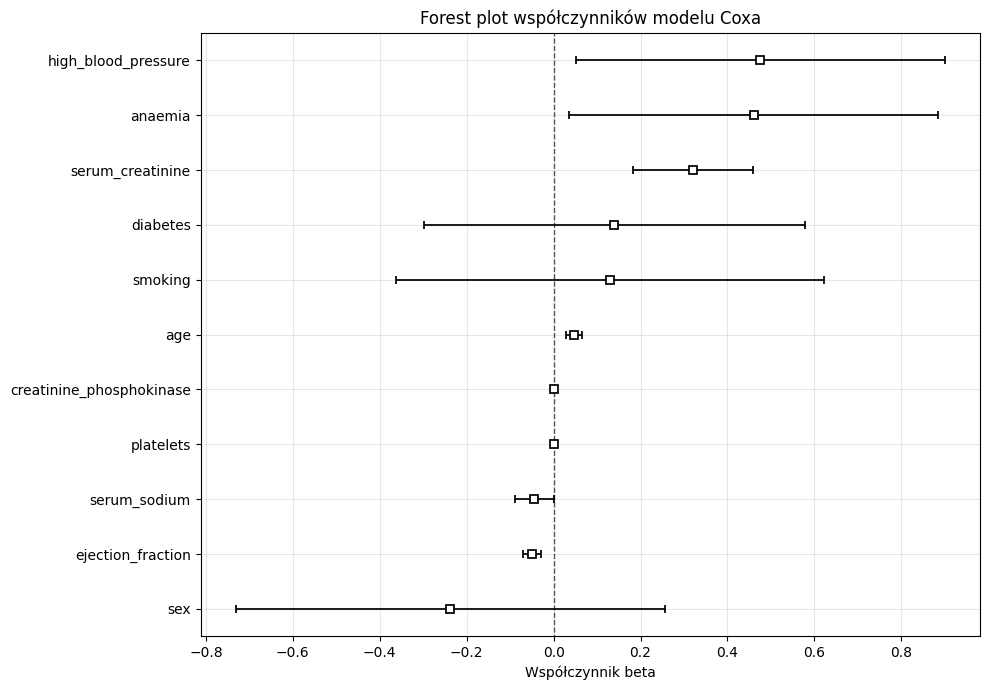

In [14]:
plt.figure(figsize=(10, 7))
cph.plot()
plt.title("Forest plot współczynników modelu Coxa")
plt.xlabel("Współczynnik beta")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_forest_plot_beta.png"), dpi=300)
plt.show()

## 8. Ranking Hazard Ratio

Poniższy wykres pokazuje wpływ zmiennych w skali Hazard Ratio. Linia pionowa przy wartości 1 oznacza brak wpływu na hazard.

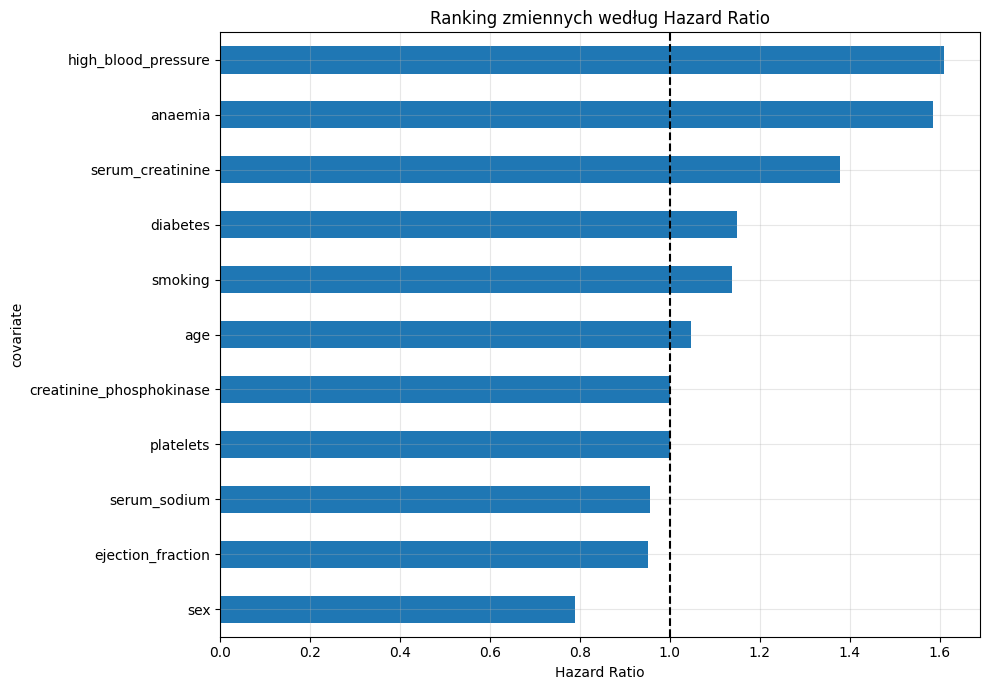

In [15]:
hr = cph.summary["exp(coef)"].sort_values()

plt.figure(figsize=(10, 7))
hr.plot(kind="barh")
plt.axvline(1, linestyle="--", color="black")
plt.title("Ranking zmiennych według Hazard Ratio")
plt.xlabel("Hazard Ratio")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_hazard_ratio_ranking.png"), dpi=300)
plt.show()

## 9. Istotność statystyczna zmiennych

Wykres p-value pozwala szybko wskazać zmienne, które mają największe znaczenie statystyczne w modelu. Linia pionowa oznacza poziom istotności 0.05.

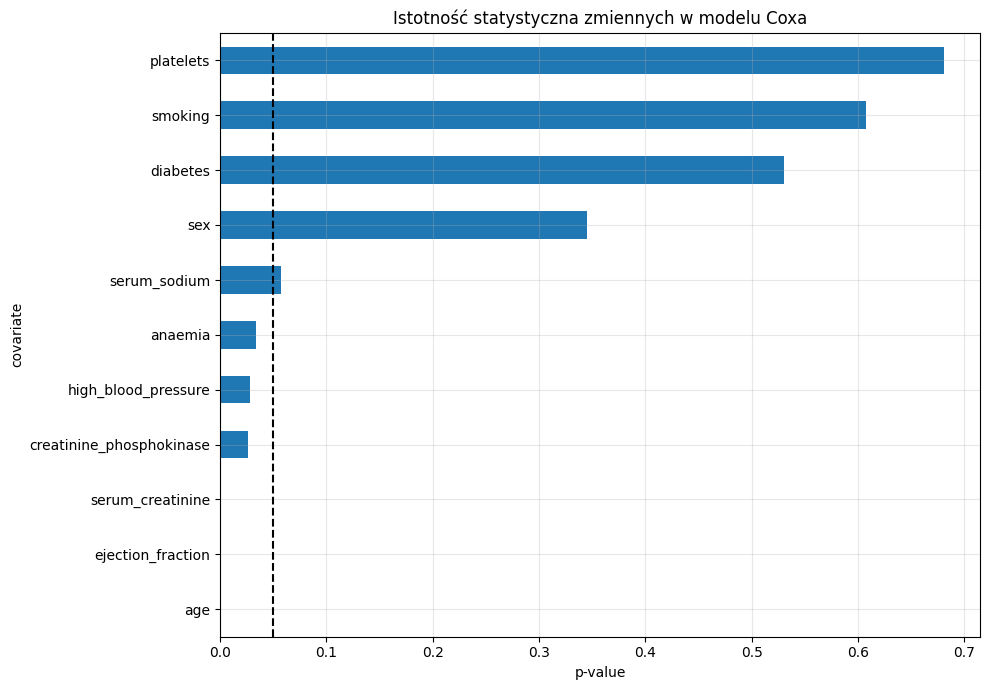

In [16]:
p_values = cph.summary["p"].sort_values(ascending=True)

plt.figure(figsize=(10, 7))
p_values.plot(kind="barh")
plt.axvline(0.05, linestyle="--", color="black")
plt.title("Istotność statystyczna zmiennych w modelu Coxa")
plt.xlabel("p-value")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_p_values.png"), dpi=300)
plt.show()

## 10. Podział pacjentów na grupy ryzyka

Na podstawie modelu Coxa można obliczyć indywidualny wynik ryzyka. Pacjentów podzielono na trzy grupy: niskiego, średniego i wysokiego ryzyka według tercyli wyniku ryzyka.

In [17]:
df_risk = df.copy()
df_risk["risk_score"] = cph.predict_partial_hazard(df)

df_risk["risk_group"] = pd.qcut(
    df_risk["risk_score"],
    q=3,
    labels=["Niskie ryzyko", "Średnie ryzyko", "Wysokie ryzyko"]
)

risk_table = df_risk.groupby("risk_group", observed=False).agg(
    liczba_pacjentow=("risk_score", "count"),
    liczba_zgonow=("DEATH_EVENT", "sum"),
    sredni_czas_obserwacji=("time", "mean"),
    sredni_wynik_ryzyka=("risk_score", "mean")
)
risk_table

,liczba_pacjentow,liczba_zgonow,sredni_czas_obserwacji,sredni_wynik_ryzyka
risk_group,,,,
Niskie ryzyko,100,9,150.840000,0.377038
Średnie ryzyko,99,27,137.525253,1.036375
Wysokie ryzyko,100,60,102.490000,4.018077


### Wykres 8. Krzywe Kaplana-Meiera dla grup ryzyka

Choć głównym modelem tej części jest Cox, wykres Kaplana-Meiera dla grup wyznaczonych na podstawie modelu pomaga wizualnie ocenić, czy model dobrze rozdziela pacjentów o różnym poziomie ryzyka.

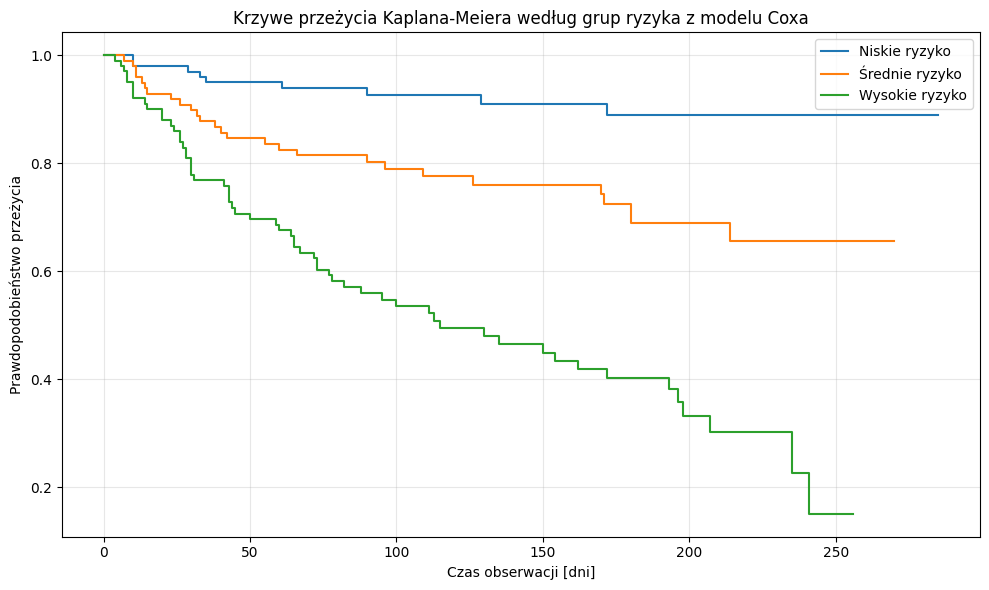

In [18]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))
for group in ["Niskie ryzyko", "Średnie ryzyko", "Wysokie ryzyko"]:
    subset = df_risk[df_risk["risk_group"] == group]
    kmf.fit(subset["time"], event_observed=subset["DEATH_EVENT"], label=group)
    kmf.plot_survival_function(ci_show=False)

plt.title("Krzywe przeżycia Kaplana-Meiera według grup ryzyka z modelu Coxa")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "08_km_grupy_ryzyka.png"), dpi=300)
plt.show()

## 11. Przewidywane funkcje przeżycia dla pacjentów o różnym ryzyku

Model Coxa może być wykorzystany do predykcji funkcji przeżycia dla konkretnych profili pacjentów. Poniżej porównano pacjenta z niskim, medianowym i wysokim wynikiem ryzyka.

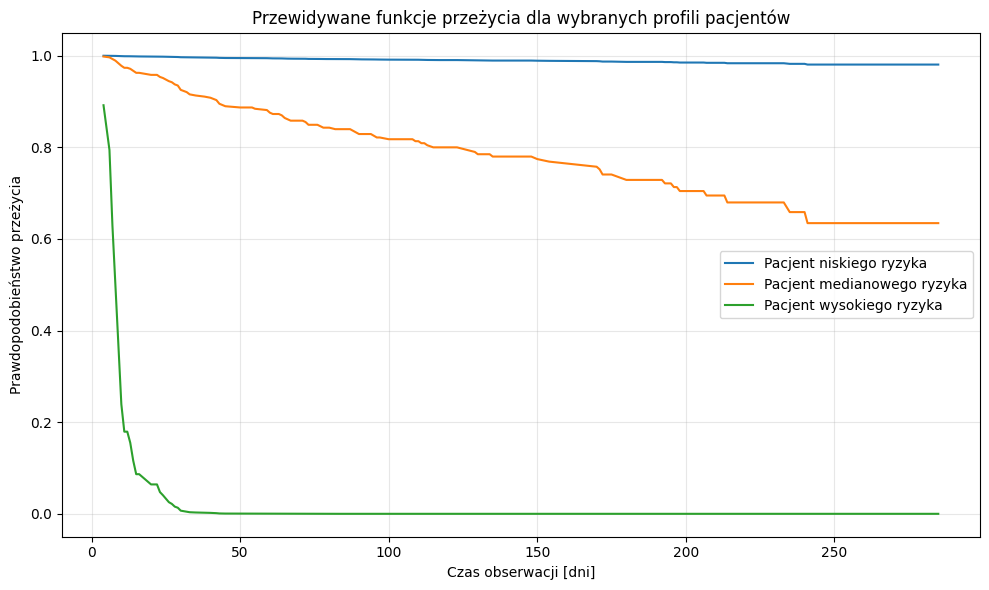

In [19]:
low_patient = df_risk.sort_values("risk_score").head(1).drop(columns=["risk_score", "risk_group"])
median_patient = df_risk.iloc[[df_risk["risk_score"].sub(df_risk["risk_score"].median()).abs().idxmin()]].drop(columns=["risk_score", "risk_group"])
high_patient = df_risk.sort_values("risk_score").tail(1).drop(columns=["risk_score", "risk_group"])

surv_low = cph.predict_survival_function(low_patient)
surv_median = cph.predict_survival_function(median_patient)
surv_high = cph.predict_survival_function(high_patient)

plt.figure(figsize=(10, 6))
plt.plot(surv_low.index, surv_low.iloc[:, 0], label="Pacjent niskiego ryzyka")
plt.plot(surv_median.index, surv_median.iloc[:, 0], label="Pacjent medianowego ryzyka")
plt.plot(surv_high.index, surv_high.iloc[:, 0], label="Pacjent wysokiego ryzyka")
plt.title("Przewidywane funkcje przeżycia dla wybranych profili pacjentów")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "09_predykcja_przezycia_profile.png"), dpi=300)
plt.show()

## 12. Wpływ wieku na funkcję przeżycia

Poniższa analiza pokazuje częściowy wpływ wieku przy założeniu, że pozostałe zmienne pozostają na poziomie referencyjnym wynikającym z danych.

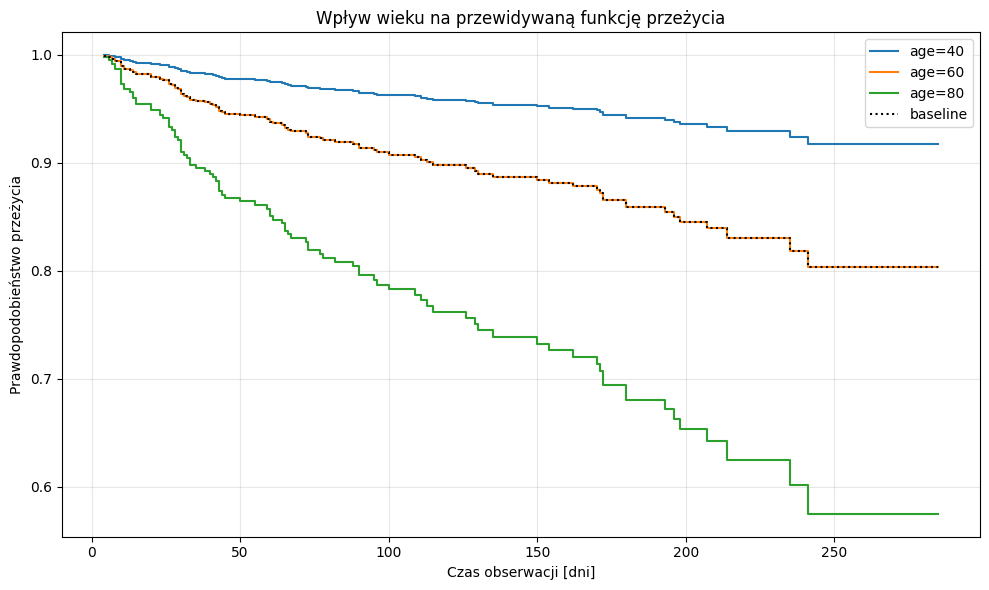

In [20]:
cph.plot_partial_effects_on_outcome(covariates="age", values=[40, 60, 80])
plt.title("Wpływ wieku na przewidywaną funkcję przeżycia")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "10_wplyw_wieku.png"), dpi=300)
plt.show()

## 13. Wpływ frakcji wyrzutowej serca

Niższa frakcja wyrzutowa oznacza gorszą wydolność serca. W modelu Coxa ta zmienna zwykle ma interpretację ochronną dla wyższych wartości: wzrost frakcji wyrzutowej powinien obniżać ryzyko zgonu.

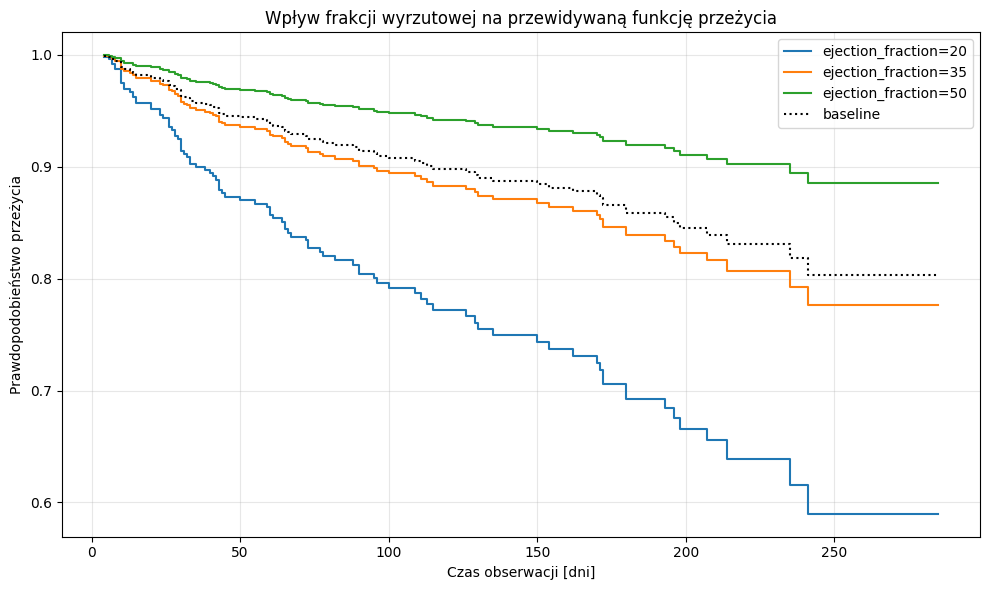

In [21]:
cph.plot_partial_effects_on_outcome(covariates="ejection_fraction", values=[20, 35, 50])
plt.title("Wpływ frakcji wyrzutowej na przewidywaną funkcję przeżycia")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "11_wplyw_frakcji_wyrzutowej.png"), dpi=300)
plt.show()

## 14. Wpływ kreatyniny w surowicy

Stężenie kreatyniny jest markerem funkcji nerek. Wysokie wartości mogą wiązać się z pogorszeniem rokowania, dlatego ta zmienna jest ważna klinicznie.

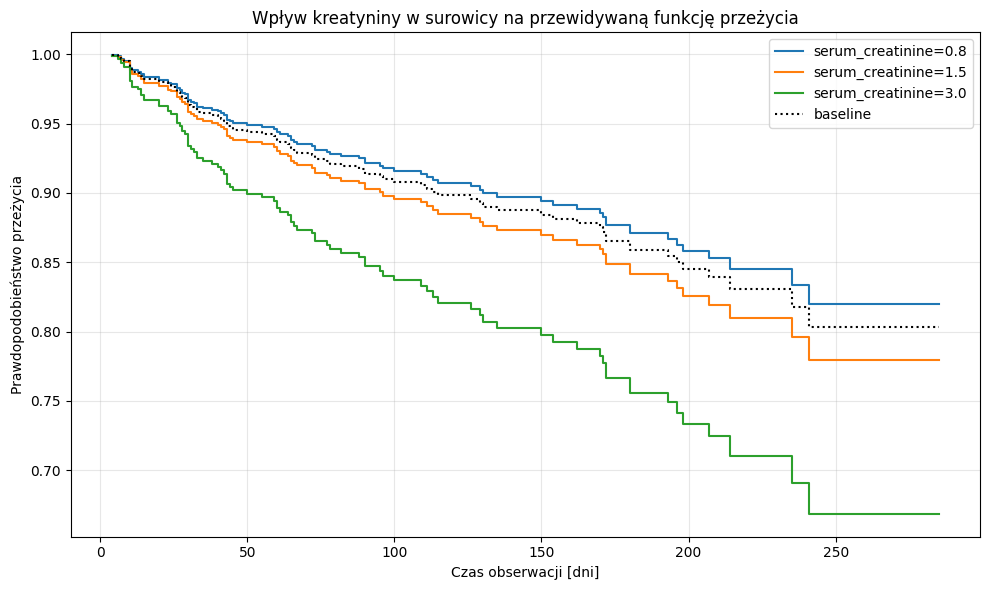

In [22]:
cph.plot_partial_effects_on_outcome(covariates="serum_creatinine", values=[0.8, 1.5, 3.0])
plt.title("Wpływ kreatyniny w surowicy na przewidywaną funkcję przeżycia")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "12_wplyw_kreatyniny.png"), dpi=300)
plt.show()

## 15. Wpływ sodu w surowicy

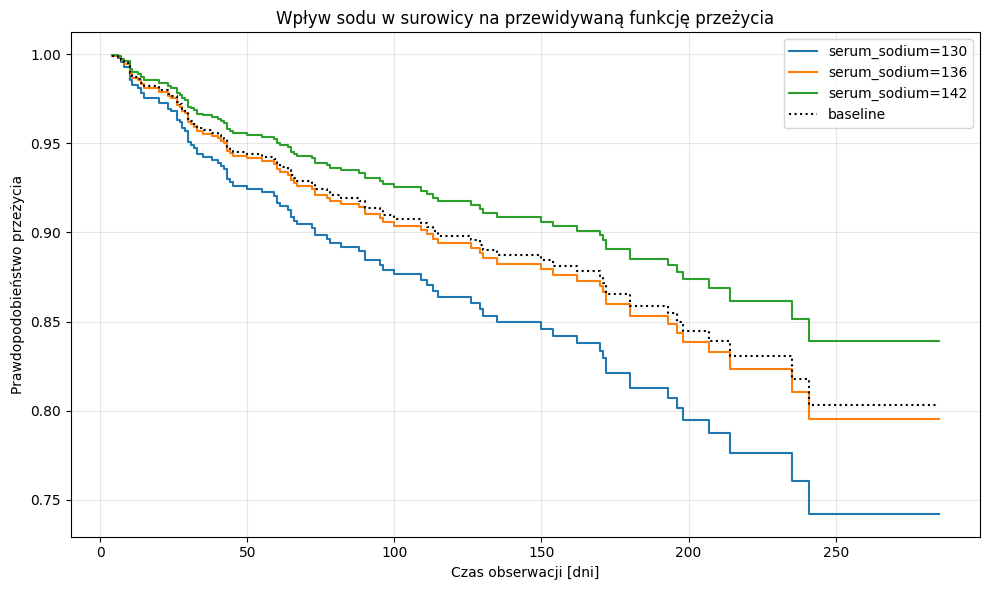

In [23]:
cph.plot_partial_effects_on_outcome(covariates="serum_sodium", values=[130, 136, 142])
plt.title("Wpływ sodu w surowicy na przewidywaną funkcję przeżycia")
plt.xlabel("Czas obserwacji [dni]")
plt.ylabel("Prawdopodobieństwo przeżycia")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "13_wplyw_sodu.png"), dpi=300)
plt.show()

## 16. Wpływ zmiennych binarnych

Dla zmiennych binarnych porównuje się dwie grupy: brak cechy (`0`) oraz występowanie cechy (`1`).

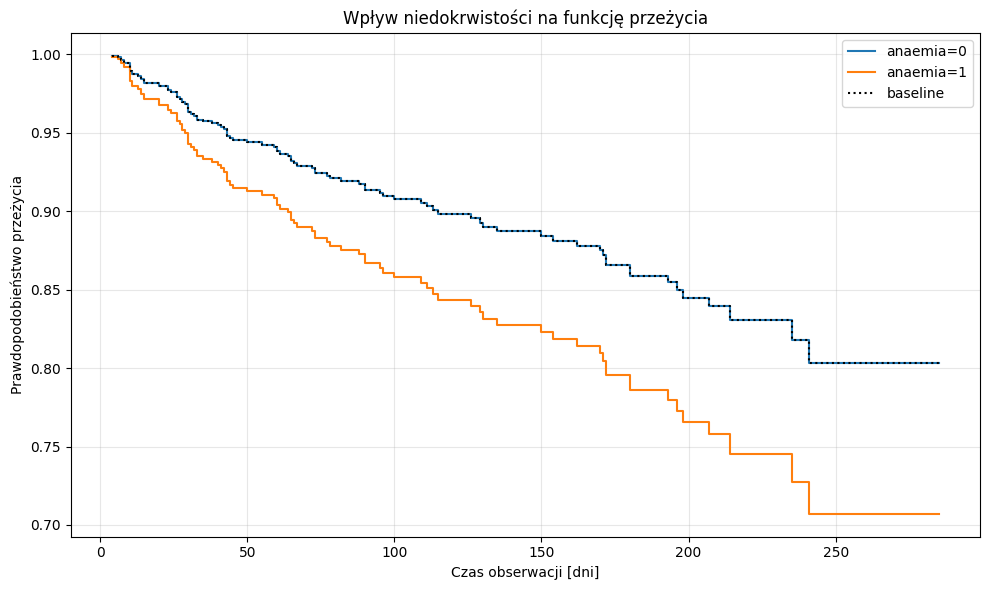

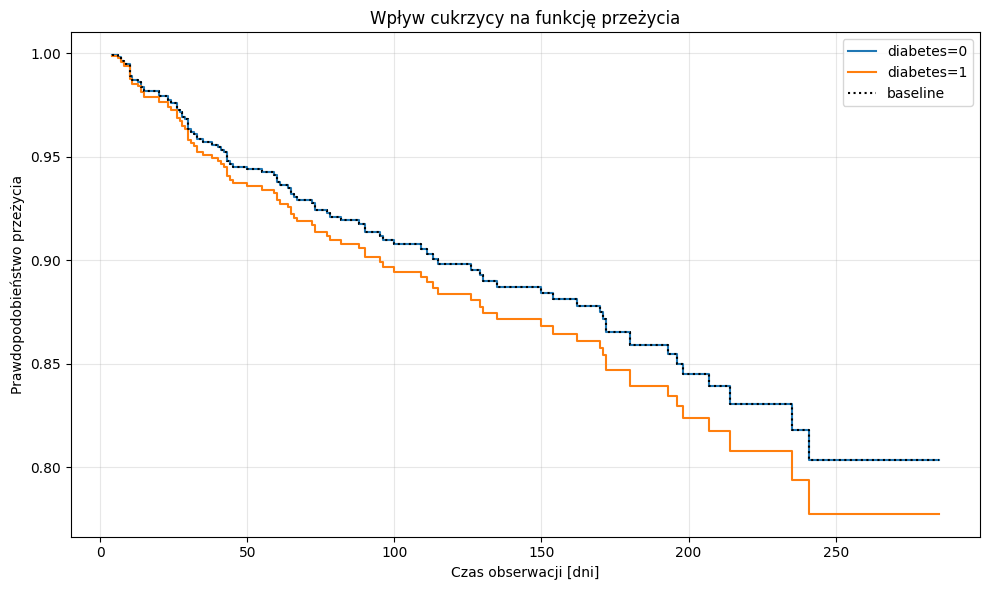

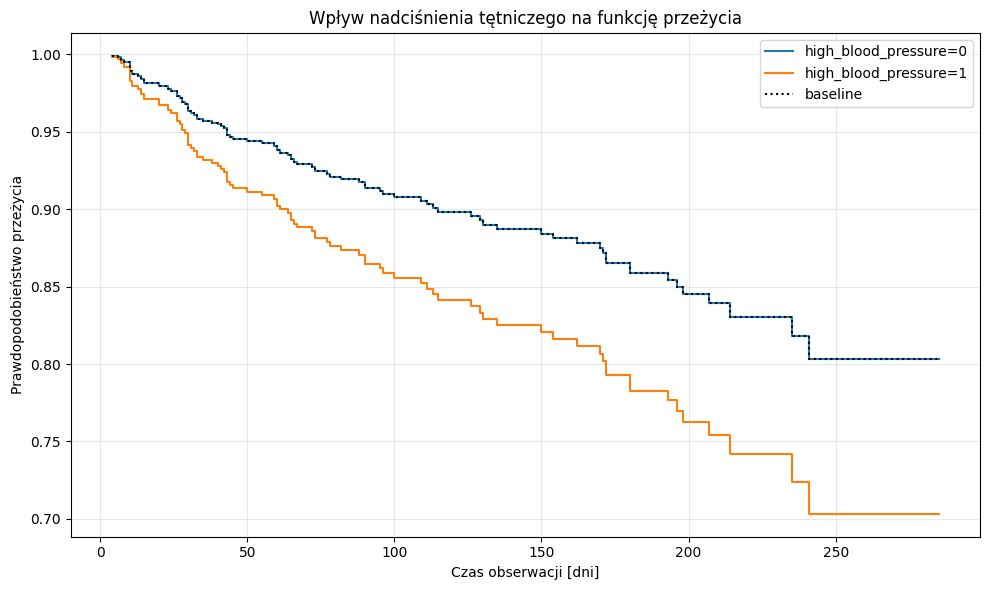

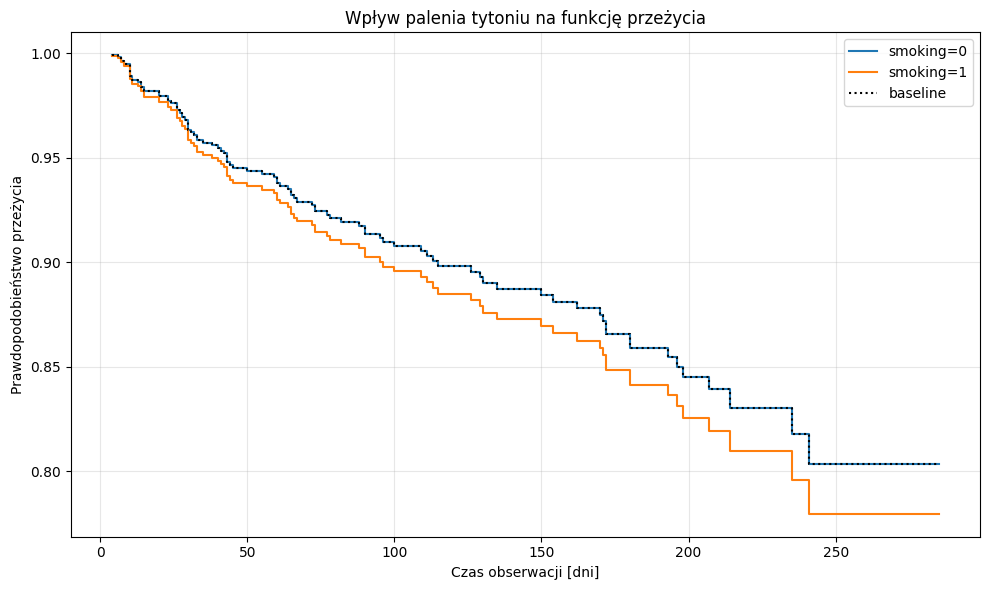

In [24]:
for var, title, filename in [
    ("anaemia", "Wpływ niedokrwistości na funkcję przeżycia", "14_wplyw_niedokrwistosci.png"),
    ("diabetes", "Wpływ cukrzycy na funkcję przeżycia", "15_wplyw_cukrzycy.png"),
    ("high_blood_pressure", "Wpływ nadciśnienia tętniczego na funkcję przeżycia", "16_wplyw_nadcisnienia.png"),
    ("smoking", "Wpływ palenia tytoniu na funkcję przeżycia", "17_wplyw_palenia.png"),
]:
    cph.plot_partial_effects_on_outcome(covariates=var, values=[0, 1])
    plt.title(title)
    plt.xlabel("Czas obserwacji [dni]")
    plt.ylabel("Prawdopodobieństwo przeżycia")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300)
    plt.show()

## 17. Ocena jakości modelu

Do oceny jakości modelu wykorzystano Concordance Index. Wartość ta opisuje, jak dobrze model porządkuje pacjentów według ryzyka. Wartość 0.5 oznacza jakość zbliżoną do losowej, a wartości bliższe 1 oznaczają lepsze uporządkowanie ryzyka.

In [25]:
model_quality = pd.DataFrame({
    "Miara": ["Concordance index", "Log-likelihood", "Partial AIC"],
    "Wartość": [cph.concordance_index_, cph.log_likelihood_, cph.AIC_partial_]
})
model_quality.to_csv(os.path.join(OUTPUT_DIR, "jakosc_modelu.csv"), encoding="utf-8-sig", index=False)
model_quality

,Miara,Wartość
0,Concordance index,0.740805
1,Log-likelihood,-468.227868
2,Partial AIC,958.455735


## 18. Test założenia proporcjonalności hazardów

Model Coxa zakłada proporcjonalność hazardów, czyli stały w czasie relatywny wpływ zmiennych na hazard. Założenie zweryfikowano testem opartym na resztach Schoenfelda. Dla każdej zmiennej analizujemy wartość `p`: wynik poniżej 0.05 może sugerować naruszenie założenia proporcjonalności hazardów.

In [26]:
ph_test = proportional_hazard_test(cph, df, time_transform="rank")
ph_results = ph_test.summary.sort_values("p")
ph_results.to_csv(os.path.join(OUTPUT_DIR, "test_proporcjonalnosci_hazardow.csv"), encoding="utf-8-sig")
ph_results

,test_statistic,p,-log2(p)
ejection_fraction,6.210616,0.012699,6.299181
serum_creatinine,3.475415,0.062287,4.004923
serum_sodium,1.732260,0.188123,2.410255
creatinine_phosphokinase,1.106899,0.292757,1.772224
smoking,0.327710,0.567011,0.818552
sex,0.260751,0.609605,0.714054
platelets,0.113767,0.735896,0.442426
high_blood_pressure,0.111031,0.738973,0.436407
age,0.029723,0.863121,0.212365
anaemia,0.008139,0.928116,0.107622


### Wykres 18. Wyniki testu proporcjonalności hazardów

Na wykresie przedstawiono p-value testu proporcjonalności hazardów dla poszczególnych zmiennych. Linia przy 0.05 oznacza klasyczny poziom istotności.

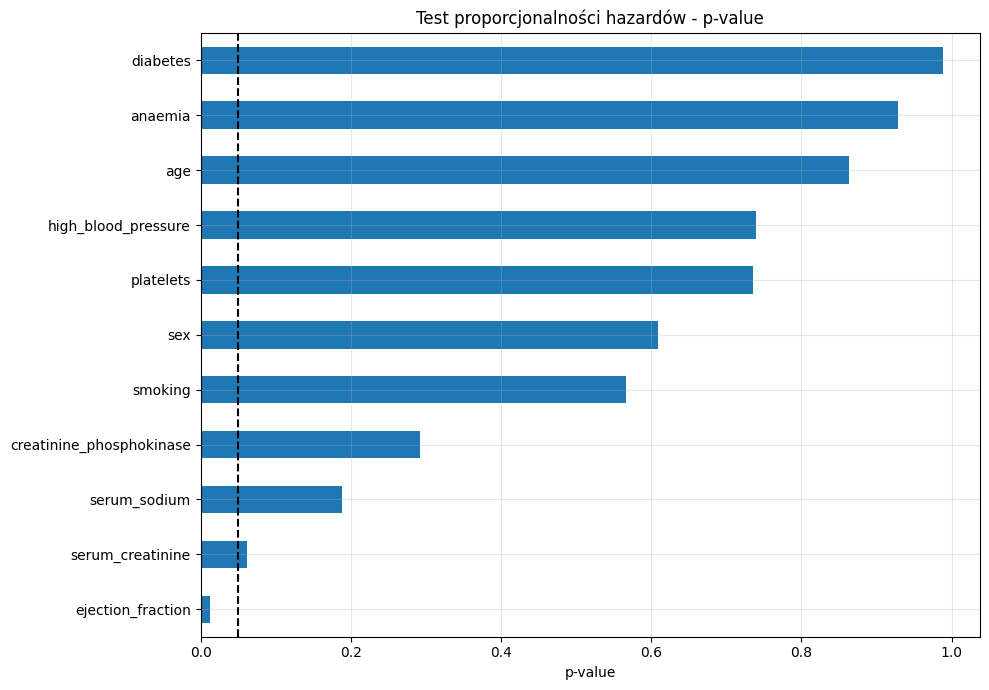

In [27]:
plt.figure(figsize=(10, 7))
ph_results["p"].sort_values().plot(kind="barh")
plt.axvline(0.05, linestyle="--", color="black")
plt.title("Test proporcjonalności hazardów - p-value")
plt.xlabel("p-value")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "18_test_ph_p_values.png"), dpi=300)
plt.show()

## 19. Interpretacja końcowa wyników

Najważniejsze wnioski z modelu należy formułować na podstawie kierunku wpływu, wartości Hazard Ratio, istotności statystycznej oraz sensu klinicznego zmiennych.

In [28]:
# Automatyczny tekst interpretacyjny na podstawie wyników modelu
interpretacje = []
for var, row in wyniki.iterrows():
    hr_value = row["Hazard Ratio"]
    p_value = row["p-value"]
    if hr_value > 1:
        direction = "zwiększa hazard zgonu"
    else:
        direction = "zmniejsza hazard zgonu"
    significance = "istotny statystycznie" if p_value < 0.05 else "nieistotny statystycznie przy poziomie 0.05"
    interpretacje.append({
        "Zmienna": var,
        "Hazard Ratio": round(hr_value, 4),
        "p-value": round(p_value, 4),
        "Interpretacja": f"Zmienna {direction}; wynik jest {significance}."
    })

interpretacje_df = pd.DataFrame(interpretacje)
interpretacje_df.to_csv(os.path.join(OUTPUT_DIR, "interpretacje_zmiennych.csv"), encoding="utf-8-sig", index=False)
interpretacje_df

,Zmienna,Hazard Ratio,p-value,Interpretacja
0,age,1.0475,0.0000,Zmienna zwiększa hazard zgonu; wynik jest isto...
1,ejection_fraction,0.9522,0.0000,Zmienna zmniejsza hazard zgonu; wynik jest ist...
2,serum_creatinine,1.3786,0.0000,Zmienna zwiększa hazard zgonu; wynik jest isto...
3,creatinine_phosphokinase,1.0002,0.0260,Zmienna zwiększa hazard zgonu; wynik jest isto...
4,high_blood_pressure,1.6092,0.0278,Zmienna zwiększa hazard zgonu; wynik jest isto...
5,anaemia,1.5843,0.0338,Zmienna zwiększa hazard zgonu; wynik jest isto...
6,serum_sodium,0.9568,0.0575,Zmienna zmniejsza hazard zgonu; wynik jest nie...
7,sex,0.7886,0.3452,Zmienna zmniejsza hazard zgonu; wynik jest nie...
8,diabetes,1.1501,0.5307,Zmienna zwiększa hazard zgonu; wynik jest niei...
9,smoking,1.1376,0.6078,Zmienna zwiększa hazard zgonu; wynik jest niei...


## 20. Wnioski do projektu

Na podstawie przeprowadzonej analizy semiparametrycznej można sformułować następujące wnioski:

1. Model Coxa pozwala ocenić wpływ zmiennych klinicznych na hazard zgonu bez konieczności przyjmowania konkretnego rozkładu czasu przeżycia.
2. Najważniejszą miarą interpretacyjną jest Hazard Ratio. Wartości powyżej 1 oznaczają wzrost ryzyka zgonu, a wartości poniżej 1 oznaczają spadek ryzyka.
3. W analizowanym zbiorze szczególnie ważne okazały się zmienne związane z wiekiem pacjenta, frakcją wyrzutową serca oraz stężeniem kreatyniny w surowicy.
4. Wyższy wiek oraz wyższe stężenie kreatyniny wiążą się ze zwiększeniem hazardu zgonu, natomiast wyższa frakcja wyrzutowa serca ma charakter ochronny.
5. Wartość Concordance Index wskazuje, że model posiada umiarkowaną zdolność porządkowania pacjentów według ryzyka.
6. Test proporcjonalności hazardów pozwala ocenić, czy założenie modelu Coxa jest spełnione dla poszczególnych zmiennych. Ewentualne naruszenia tego założenia należy odnotować w interpretacji i traktować jako ograniczenie modelu.
7. Predykcyjne krzywe przeżycia oraz krzywe dla grup ryzyka pokazują, że model różnicuje pacjentów o odmiennym profilu ryzyka, co potwierdza użyteczność modelu w analizie przeżycia pacjentów z niewydolnością serca.

## 21. Pliki wynikowe

Wszystkie wykresy i tabele zostały zapisane w folderze `wyniki_semiparametryczne_cox`. Można je wykorzystać w prezentacji, raporcie lub aplikacji projektowej.

In [29]:
print("Wygenerowane pliki:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file)

Wygenerowane pliki:
- 01_struktura_zdarzen.png
- 02_rozklad_wieku.png
- 03_rozklad_frakcji_wyrzutowej.png
- 04_macierz_korelacji.png
- 05_forest_plot_beta.png
- 06_hazard_ratio_ranking.png
- 07_p_values.png
- 08_km_grupy_ryzyka.png
- 09_predykcja_przezycia_profile.png
- 10_wplyw_wieku.png
- 11_wplyw_frakcji_wyrzutowej.png
- 12_wplyw_kreatyniny.png
- 13_wplyw_sodu.png
- 14_wplyw_niedokrwistosci.png
- 15_wplyw_cukrzycy.png
- 16_wplyw_nadcisnienia.png
- 17_wplyw_palenia.png
- 18_test_ph_p_values.png
- interpretacje_zmiennych.csv
- jakosc_modelu.csv
- statystyki_opisowe.csv
- test_proporcjonalnosci_hazardow.csv
- wyniki_modelu_coxa.csv
